# Phase IV — Daily Traffic Volume and Motor Vehicle Crashes in NYC

**Project repository:** https://github.com/VincentPit/ds_in_da_wild

**Group members:** Qiaohao Hu (qh252), Jinyue (Carrie) Wang (jw2796), Junyi Li (jl4724), Wenzhuo Zhang (wz475)

**Submitted:** April 27, 2026

---

## 1) Introduction

### Research question

> **How is daily roadway traffic volume associated with motor vehicle collision frequency and injury severity in NYC?**

We focus on three concrete sub-questions, each tied to a preregistered hypothesis in Section 4:

1. After accounting for borough, day-of-week, season, and weather, do higher-traffic days produce more crashes?
2. Does rain make crashes more severe (more injuries per crash), not just more frequent?
3. Does the *mix* of who gets hurt — pedestrians, cyclists, motorists — shift on the busiest days?

### Why this matters

NYC averages **~600 reported motor-vehicle crashes per day** and roughly **50,000 injuries per year** in the open NYPD record. Vision Zero, the city's flagship traffic-safety program launched in 2014, set a goal of *zero* traffic deaths and frames its policy levers (lower speed limits, signal retiming, protected bike lanes) around exposure — the assumption that more vehicle-miles produce more crashes. Yet the open-data evidence on the *shape* of that exposure–outcome curve at the daily city level is surprisingly thin: most prior NYC traffic-safety analyses use crash counts alone or VMT estimates from regional transportation models, not direct sensor-measured daily volume.

By pairing the NYC DOT Automated Traffic Volume Counts (ATVC) sensor network with the NYPD Motor Vehicle Collisions record over Jul 2012–Dec 2025, we can ask the exposure question directly: *holding borough, weekday, season, and weather fixed, does an extra million vehicle passages translate into measurably more crashes?* And by joining ERA5 weather, we can ask whether rain's effect is on **frequency** (the standard "wet-road" intuition) or on **severity** (per-crash injury rate). These distinctions matter for policy: the right response to "more crashes on rainy days" is different if rain mostly produces more fender-benders versus producing more serious injuries.

A future interviewer or hiring manager reading this notebook should be able to follow the data, the model choice, and the policy interpretation without prior NYC-specific background — that is the audience we are writing for.


## 2) Data Description

This is an abridged version of our Phase 2 description. **Full description (all questions):** see the Phase 2 notebook at [https://github.com/VincentPit/ds_in_da_wild/blob/main/phase2_eda.ipynb](https://github.com/VincentPit/ds_in_da_wild/blob/main/phase2_eda.ipynb). **Raw data folder:** [https://github.com/VincentPit/ds_in_da_wild/tree/main/data](https://github.com/VincentPit/ds_in_da_wild/tree/main/data).

| # | Dataset | Source | Role |
|---|---|---|---|
| 1 | NYC DOT Automated Traffic Volume Counts (ATVC) | NYC Open Data, Socrata `7ym2-wayt` | **Exposure variable** — daily vehicle counts from permanent ATR sensors, 2012–2025 |
| 2 | Motor Vehicle Collisions – Crashes | NYC Open Data, `h9gi-nx95` | **Outcome variable** — crash records with borough, victim-type injury counts, 2012–2026 |
| 3 | Open-Meteo ERA5 reanalysis (NYC daily) | `archive-api.open-meteo.com` | **Confounder** — daily mean temp (°F), total precip (mm) at NYC coords |

**Rows / columns we use:**

- **ATVC city-day** ([data/atvc_daily.csv](data/atvc_daily.csv)): 3,905 rows; columns `Date`, `daily_vol`, `n_segments`. We derive `vol_M = daily_vol / 1e6`.
- **ATVC borough-day** ([data/atvc_boro_daily.csv](data/atvc_boro_daily.csv)): 6,674 rows; columns `Date`, `boro`, `daily_vol`, `n_segments`. Borough names normalised to upper-case (`THE BRONX → BRONX`).
- **Crashes raw** ([data/Motor_Vehicle_Collisions_-_Crashes_20260225.csv](data/Motor_Vehicle_Collisions_-_Crashes_20260225.csv)): 2.24 M rows; we keep `CRASH DATE`, `BOROUGH`, `COLLISION_ID`, and the five `NUMBER OF … INJURED/KILLED` columns.
- **ERA5 weather** ([data/era5_nyc_daily.csv](data/era5_nyc_daily.csv)): 5,114 rows fetched once from Open-Meteo for NYC (40.7128, -74.006), columns `Date`, `temp_F`, `precip_mm`.

**Why these columns are relevant:** `vol_M` is the exposure measure; `daily_crashes` (count per borough-day) is the H1 outcome; `injury_rate = persons_injured / daily_crashes` is the H2 outcome; the three victim-type columns (`ped_injured`, `cyc_injured`, `motorist_injured`) are the H3 outcome. Borough, month, weekday, temperature, and precipitation are the controls preregistered to absorb seasonal/spatial/weather confounding.

**What we do NOT use:** the Climate Projections decadal dataset (no daily granularity) and the Hyperlocal Temperature dataset (only Jun 2018–Oct 2019, insufficient panel coverage). Both are described in Phase 2 for completeness.


## 3) Data Collection & Cleaning

All cleaning is implemented as a standalone Python script — **[phase4_clean.py](https://github.com/VincentPit/ds_in_da_wild/blob/main/phase4_clean.py)** — that reads raw inputs from `data/` and writes two analysis-ready CSVs:

- **`data/phase4_borough_day.csv`** — 18,693 rows (5 boroughs × 3,739 dates). Used for H1.
- **`data/phase4_city_day.csv`** — 3,739 rows (one per date). Used for H2 and H3.

**Cleaning steps** (one paragraph each, more detail in the script):

1. **Load.** ATVC city totals (`atvc_daily.csv`), ATVC borough totals (`atvc_boro_daily.csv`), NYPD crashes (raw CSV, 9 columns retained), and ERA5 weather (pre-fetched once and cached in `data/era5_nyc_daily.csv` so that the cleaner has no network dependency). Date columns parsed to `datetime`; numeric columns coerced with `errors='coerce'` and `NaN → 0` for crash counts (an absent injury count is a zero, not an unknown).

2. **Aggregate, normalise, and merge.** Crashes are aggregated to borough-day (`COLLISION_ID` count, summed injury columns by victim type) and to city-day. ATVC borough names are upper-cased and `THE BRONX → BRONX` so they join 1-to-1 with the NYPD borough field. The borough-day panel is the inner-join of borough crash aggregates and city-wide ATVC totals (one shared `vol_M` per date), left-joined to borough-level ATVC and to ERA5 weather. The city-day panel is the inner-join of city-wide crash aggregates and city-wide ATVC, left-joined to ERA5. Calendar features (`year`, `month`, `dow_num`, `day_of_week`, `is_weekend`) are added at the end.

**Differences from Phase 2.** None substantive. The Phase 2 EDA notebook builds the same panel inline; here we extract it into a script so the analysis notebook can `pd.read_csv` directly. The borough-day panel that powers H1 has the same row count (18,693) and the same `vol_M` definition as the Phase 2 Section 4.8 panel.


## 4) Preregistration Statement

These are the three hypotheses we registered on April 8, 2026, after Phase 2 EDA but before fitting the Phase 4 models. They are reproduced from the Phase 3 submission with no changes other than minor wording. All α = 0.05 and we commit to reporting effect size and our substantive interpretation regardless of significance.

### H1 — Traffic volume and daily crashes (one-sided)

**Hypothesis.** After controlling for borough, day-of-week, month, and weather, higher daily traffic volume is associated with a higher expected count of motor-vehicle crashes in NYC.

**Domain context.** Vision Zero and most exposure-based traffic-safety models assume a positive volume–crash gradient; a recent meta-analysis (Elvik 2013, *Accident Analysis & Prevention*) finds that crash counts scale roughly with the 0.7–0.9 power of vehicle exposure across most road environments. The Phase 2 EDA's borough-panel OLS gave a positive `vol_M` coefficient (+12.3, p = 0.009), motivating a one-sided test rather than a two-sided one.

**Analysis.** Borough-day panel (n = 18,693). Outcome `daily_crashes` is an integer count with overdispersion (Phase 2 §4.9 Cameron–Trivedi rejected Poisson at p ≈ 0). Fit a **Negative Binomial GLM** with log link via `statsmodels.formula.api.glm(..., family=sm.families.NegativeBinomial())`:

$$\log \mathbb{E}[\texttt{daily\_crashes}] = \beta_0 + \beta_1\,\texttt{vol\_M} + \beta_2\,\texttt{is\_weekend} + \gamma_b\,C(\texttt{BOROUGH}, \text{ref}=\text{Bronx}) + \delta_m\,C(\texttt{month}) + \beta_3\,\texttt{temp\_F} + \beta_4\,\texttt{precip\_mm}.$$

Test $H_0: \beta_1 \le 0$ vs. $H_1: \beta_1 > 0$ at α = 0.05 using the Wald z-test. Report point estimate, SE, 95% CI, and incidence-rate ratio $\exp(\beta_1)$.

### H2 — Precipitation and crash injury severity (two-sided)

**Hypothesis.** Daily precipitation is positively associated with the per-crash injury rate (`injuries / crashes`) in NYC — that is, rain raises *severity*, not just frequency.

**Domain context.** Wet pavement reduces tire friction and lengthens stopping distances, which intuitively raises severity. But survey evidence is mixed: drivers tend to slow down in rain, which can offset the friction effect. The Phase 2 EDA's raw correlation between `precip_mm` and `injuries_per_crash` was small (r = 0.028) but unconditioned on volume or season, so a controlled two-sided test is appropriate.

**Analysis.** City-day panel (n = 3,739; no zero-crash days, so the ratio is always defined). Fit OLS with HC3 heteroskedasticity-robust SEs:

$$\texttt{injury\_rate} = \beta_0 + \beta_1\,\texttt{precip\_mm} + \beta_2\,\texttt{temp\_F} + \beta_3\,\texttt{vol\_M} + \beta_4\,\texttt{is\_weekend} + \delta_m\,C(\texttt{month}) + \varepsilon.$$

Test $H_0: \beta_1 = 0$ vs. $H_1: \beta_1 \ne 0$ at α = 0.05 using a t-test. Report $\beta_1$, robust SE, 95% CI, and adjusted $R^2$.

### H3 — Victim mix across traffic-volume quintiles (chi-square)

**Hypothesis.** The composition of injured victims by road-user type (pedestrian / cyclist / motorist) differs across days grouped by city-wide traffic-volume quintile.

**Domain context.** Vulnerable road users (pedestrians and cyclists) have less protection in any crash than motorists. If high-volume days disproportionately *expose* vulnerable users — say, because pedestrian and cycling activity tracks vehicle activity in commercial districts — the share of injured pedestrians and cyclists should rise with volume. If, instead, high-volume days are dominated by car-on-car expressway crashes, motorist share should rise.

**Analysis.** City-day panel; rank dates by `vol_M` and split into five equal-sized quintiles Q1–Q5. Sum injured victims by type within each quintile to form a 5 × 3 contingency table, then run a Pearson chi-square test of independence (`scipy.stats.chi2_contingency`). Report chi-square, df = 8, p-value, Cramér's V, and standardized residuals.

### Evaluation criteria (preregistered)

α = 0.05 for all three. We report point estimate, uncertainty, test statistic, p-value, and substantive interpretation regardless of significance, and we discuss effect size and practical significance in addition to the formal test result. We will not add, drop, or swap hypotheses based on what we observe.


## 5) Data Analysis & Evaluation of Significance

### 5.0 Setup — load the analysis-ready CSVs

Both panels were produced by the standalone `phase4_clean.py` script. We load them here directly; this notebook does not touch the raw data.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*overflow encountered.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

DATA = Path("data")
boro_panel = pd.read_csv(DATA / "phase4_borough_day.csv", parse_dates=["Date"])
city_panel = pd.read_csv(DATA / "phase4_city_day.csv",    parse_dates=["Date"])

print(f"borough-day panel: {len(boro_panel):,} rows  "
      f"({boro_panel.Date.nunique()} dates x {boro_panel.BOROUGH.nunique()} boroughs)")
print(f"city-day    panel: {len(city_panel):,} rows  "
      f"({city_panel.Date.min().date()} -> {city_panel.Date.max().date()})")
print(f"weather coverage:  boro temp {boro_panel.temp_F.notna().mean():.1%}  "
      f"city temp {city_panel.temp_F.notna().mean():.1%}")
print()
print("Sample of borough panel:")
print(boro_panel.head(2).to_string(index=False))


borough-day panel: 18,693 rows  (3739 dates x 5 boroughs)
city-day    panel: 3,739 rows  (2012-07-01 -> 2025-12-11)
weather coverage:  boro temp 100.0%  city temp 100.0%

Sample of borough panel:
      Date  BOROUGH  daily_crashes  persons_injured  persons_killed  ped_injured  cyc_injured  motorist_injured  city_daily_volume  city_seg_count   vol_M  boro_daily_volume  boro_seg_count  temp_F  precip_mm  year  month  dow_num day_of_week  is_weekend
2012-07-01    BRONX             39             11.0             0.0            1            2                 8            44390.0               4 0.04439                NaN             NaN    81.6        1.7  2012      7        6      Sunday           1
2012-07-01 BROOKLYN            135             47.0             0.0           11            4                32            44390.0               4 0.04439            30576.0             2.0    81.6        1.7  2012      7        6      Sunday           1


### 5.1 Hypothesis 1 — Traffic volume → daily crashes (Negative Binomial GLM)

We fit the preregistered model:

```
NegBin GLM, log link
daily_crashes  ~  vol_M + is_weekend + C(BOROUGH, ref=Bronx) + C(month) + temp_F + precip_mm
```

The Wald z-test on `vol_M` is two-sided by default; we convert to the preregistered one-sided p-value
( $H_1: \beta_1 > 0$ ) by halving when the sign is positive.

In [2]:
# Set Bronx as reference borough explicitly (preregistered)
from statsmodels.formula.api import glm

# Sanity check: borough panel has the expected size
assert len(boro_panel) == 18_693, len(boro_panel)
assert set(boro_panel.BOROUGH.unique()) == {"BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"}

formula_h1 = (
    "daily_crashes ~ vol_M + is_weekend "
    "+ C(BOROUGH, Treatment(reference='BRONX')) "
    "+ C(month) + temp_F + precip_mm"
)
m_h1 = glm(formula_h1, data=boro_panel,
           family=sm.families.NegativeBinomial()).fit()

print(m_h1.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:          daily_crashes   No. Observations:                18693
Model:                            GLM   Df Residuals:                    18673
Model Family:        NegativeBinomial   Df Model:                           19
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -94239.
Date:                Mon, 27 Apr 2026   Deviance:                       3439.8
Time:                        18:25:02   Pearson chi2:                 2.99e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3276
Covariance Type:            nonrobust                                         
                                                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

/Users/stephenlee/Desktop/WildDs/ds_in_da_wild/.venv/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [3]:
# ---- Preregistered one-sided test on vol_M ----
b1   = m_h1.params["vol_M"]
se1  = m_h1.bse["vol_M"]
z    = b1 / se1
p_two = m_h1.pvalues["vol_M"]
p_one = p_two / 2 if b1 > 0 else 1 - p_two / 2

ci_low, ci_high = m_h1.conf_int().loc["vol_M"].tolist()
irr = np.exp(b1)
irr_lo, irr_hi = np.exp(ci_low), np.exp(ci_high)

print("=== H1 — vol_M coefficient (preregistered one-sided test, alpha=0.05) ===")
print(f"  beta1 (log-IRR per +1M vehicles): {b1:.4f}")
print(f"  SE:                                {se1:.4f}")
print(f"  Wald z:                            {z:.3f}")
print(f"  Two-sided Wald p:                  {p_two:.4g}")
print(f"  One-sided p (H1: beta1 > 0):       {p_one:.4g}")
print(f"  95% CI (beta1):                    [{ci_low:.4f}, {ci_high:.4f}]")
print()
print(f"  IRR per +1M vehicles:              {irr:.4f}")
print(f"  95% CI (IRR):                      [{irr_lo:.4f}, {irr_hi:.4f}]")
print()
decision = "REJECT H0" if (p_one < 0.05 and b1 > 0) else "FAIL TO REJECT H0"
print(f"  Decision at alpha=0.05:            {decision}")


=== H1 — vol_M coefficient (preregistered one-sided test, alpha=0.05) ===
  beta1 (log-IRR per +1M vehicles): 0.2044
  SE:                                0.1786
  Wald z:                            1.144
  Two-sided Wald p:                  0.2524
  One-sided p (H1: beta1 > 0):       0.1262
  95% CI (beta1):                    [-0.1456, 0.5544]

  IRR per +1M vehicles:              1.2268
  95% CI (IRR):                      [0.8645, 1.7409]

  Decision at alpha=0.05:            FAIL TO REJECT H0


**Interpretation of H1.**

- *Summary.* The `vol_M` coefficient is **+0.204** (sign matches the preregistered direction) with SE = 0.179, giving a Wald z = 1.14 and a one-sided p-value of **0.126**. Under the preregistered GLM with `family=NegativeBinomial()` (which fixes the dispersion parameter at α = 1), we **fail to reject H₀** at α = 0.05. The point-estimate IRR is 1.23 — i.e. each additional million city-wide vehicle passages is associated with a ~23% multiplicative bump in expected per-borough crashes — but the 95% CI [0.86, 1.74] straddles 1, so we cannot rule out a null effect under this specification.
- *Predicting.* The borough fixed effects are very precisely estimated (all z > |19|): Brooklyn IRR ≈ exp(0.78) = 2.18×, Queens ≈ 1.83×, Manhattan ≈ 1.57×, Staten Island ≈ exp(−1.23) = 0.29×, all relative to the Bronx baseline. Weekends are associated with a ~16% lower expected count (exp(−0.174) ≈ 0.84). Months May–October all add to expected crashes relative to January, with July the peak (exp(0.45) ≈ 1.56×). Temperature has a small negative coefficient (−0.005, p < 0.001) once month is in the model, suggesting the raw positive temp–crash correlation is a seasonal artifact.
- *Outliers / oddities.* The most important caveat is that the preregistered GLM family fixes α = 1, which is a much *larger* dispersion than the data actually exhibit (Phase 2 §4.9 ML estimate: α ≈ 0.16). Inflating the assumed dispersion inflates the SE on `vol_M` — the §6.1 robustness check refits the same specification with `smf.negativebinomial(...)` (which estimates α jointly) and gets the same point estimate (0.207) but a much smaller SE (0.076), producing a one-sided p of **0.003** and a clear rejection. So the failure to reject under the preregistered specification is driven mostly by the registered family's default α. We report both per the preregistered evaluation criteria and discuss the implication in the Conclusions.

### 5.2 Hypothesis 2 — Precipitation → injuries per crash (OLS, HC3 SE)

We fit the preregistered model:

```
OLS with HC3 robust standard errors
injury_rate = persons_injured / daily_crashes
injury_rate  ~  precip_mm + temp_F + vol_M + is_weekend + C(month)
```

There are zero days with `daily_crashes == 0` in the city-day panel, so `injury_rate` is always defined.

In [4]:
# Sanity: no zero-crash days, so injury_rate is well-defined everywhere
assert (city_panel["daily_crashes"] == 0).sum() == 0

city = city_panel.copy()
city["injury_rate"] = city["persons_injured"] / city["daily_crashes"]

formula_h2 = ("injury_rate ~ precip_mm + temp_F + vol_M + is_weekend + C(month)")
m_h2 = smf.ols(formula_h2, data=city).fit(cov_type="HC3")

print(m_h2.summary())


                            OLS Regression Results                            
Dep. Variable:            injury_rate   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     19.66
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           9.88e-52
Time:                        18:25:02   Log-Likelihood:                 2350.2
No. Observations:                3739   AIC:                            -4668.
Df Residuals:                    3723   BIC:                            -4569.
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.2154      0.012     17.

In [5]:
b   = m_h2.params["precip_mm"]
se  = m_h2.bse["precip_mm"]
t   = b / se
p   = m_h2.pvalues["precip_mm"]
ci_lo, ci_hi = m_h2.conf_int().loc["precip_mm"].tolist()

print("=== H2 — precip_mm coefficient (preregistered two-sided test, alpha=0.05) ===")
print(f"  beta1 (injuries per crash per +1 mm rain): {b:.6f}")
print(f"  HC3 SE:                                    {se:.6f}")
print(f"  t (HC3):                                   {t:.3f}")
print(f"  Two-sided p (HC3):                         {p:.4g}")
print(f"  95% CI:                                    [{ci_lo:.6f}, {ci_hi:.6f}]")
print(f"  Adj R^2 (model):                           {m_h2.rsquared_adj:.4f}")
decision = "REJECT H0" if p < 0.05 else "FAIL TO REJECT H0"
print(f"  Decision at alpha=0.05:                    {decision}")

# Practical effect size: change in injury_rate from a wet day (~10 mm) vs a dry day
print(f"\nPractical effect: a 10 mm-rain day is associated with a "
      f"{10*b:+.4f} change in injuries per crash, "
      f"vs a baseline mean injury_rate of {city['injury_rate'].mean():.3f}.")


=== H2 — precip_mm coefficient (preregistered two-sided test, alpha=0.05) ===
  beta1 (injuries per crash per +1 mm rain): 0.000268
  HC3 SE:                                    0.000276
  t (HC3):                                   0.974
  Two-sided p (HC3):                         0.3301
  95% CI:                                    [-0.000272, 0.000808]
  Adj R^2 (model):                           0.0657
  Decision at alpha=0.05:                    FAIL TO REJECT H0

Practical effect: a 10 mm-rain day is associated with a +0.0027 change in injuries per crash, vs a baseline mean injury_rate of 0.348.


**Interpretation of H2.**

- *Summary.* `precip_mm` has a coefficient of **+2.7 × 10⁻⁴ injuries-per-crash per mm of rain**, HC3 SE = 2.8 × 10⁻⁴, t = 0.97, **two-sided p = 0.330** → we **fail to reject H₀**. The 95% CI [−2.7e-4, +8.1e-4] is centred near zero. Practically: a 10-mm-rain day (a fairly wet day in NYC) is associated with a +0.0027 shift in injuries per crash against a baseline mean of 0.348 — about a 0.8% relative change, swamped by ordinary day-to-day variability.
- *Predicting.* The model recovers other associations cleanly: weekends carry +0.037 more injuries per crash (z = 7.9, p < 0.001), every °F of warmth adds +0.0033 (z = 11.6), and summer months sit ~0.10–0.16 *below* the January baseline (note the January fixed effect is implicit). `vol_M` is essentially zero (−0.026, p = 0.66) once month and weekday are in. So the per-crash injury rate appears to be driven by *who is on the road* (weekday/weekend, season) rather than by *whether it is raining*.
- *Outliers / oddities.* Adjusted $R^2$ = 0.066 — the controls explain only ~7% of injury-rate variance. Most variation lives at the individual-crash level (vehicle speed, occupant counts, intersection geometry), which our daily aggregation discards. The Durbin-Watson of 0.20 indicates strong positive serial autocorrelation that the OLS standard errors don't account for; HC3 buys us heteroskedasticity robustness but not autocorrelation robustness. We flag this in Limitations.

### 5.3 Hypothesis 3 — Victim mix by traffic-volume quintile (chi-square)

We rank city-days by `vol_M` and assign each to one of five equal-sized quintiles. Within each quintile we sum injured victims by type (pedestrian, cyclist, motorist) to form a 5 × 3 contingency table.

In [6]:
city_q = city_panel.copy()
city_q["vol_quintile"] = pd.qcut(
    city_q["vol_M"], q=5,
    labels=["Q1 (low)", "Q2", "Q3", "Q4", "Q5 (high)"],
)

contingency = (
    city_q.groupby("vol_quintile", observed=True)
    [["ped_injured", "cyc_injured", "motorist_injured"]]
    .sum()
    .rename(columns={"ped_injured": "Pedestrians",
                     "cyc_injured": "Cyclists",
                     "motorist_injured": "Motorists"})
)
print("Contingency table (sum of injured victims by volume quintile x victim type):")
print(contingency.to_string())


Contingency table (sum of injured victims by volume quintile x victim type):
              Pedestrians  Cyclists  Motorists
vol_quintile                                  
Q1 (low)            20309      9487      79746
Q2                  20815      9472      81250
Q3                  22118      9368      81594
Q4                  21463      9999      83759
Q5 (high)           21632     11222      85091


In [7]:
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency.values)
n_total = contingency.values.sum()
k = min(contingency.shape) - 1
cramers_v = float(np.sqrt(chi2 / (n_total * k)))

print("=== H3 — Pearson chi-square test of independence ===")
print(f"  chi-square statistic: {chi2:.3f}")
print(f"  degrees of freedom:   {dof}")
print(f"  p-value:              {p_chi:.4g}")
print(f"  Cramer's V (effect):  {cramers_v:.4f}")
decision = "REJECT H0" if p_chi < 0.05 else "FAIL TO REJECT H0"
print(f"  Decision at alpha=0.05: {decision}")

# Standardized residuals to identify which cells drive the result
expected_df = pd.DataFrame(expected,
                           index=contingency.index,
                           columns=contingency.columns)
std_resid = (contingency - expected_df) / np.sqrt(expected_df)
print("\nStandardised residuals (>|2| highlights notable cells):")
print(std_resid.round(2).to_string())

# Within-quintile shares for interpretation
shares = (contingency.div(contingency.sum(axis=1), axis=0) * 100).round(2)
print("\nWithin-quintile shares (%) of injured by victim type:")
print(shares.to_string())


=== H3 — Pearson chi-square test of independence ===
  chi-square statistic: 178.695
  degrees of freedom:   8
  p-value:              1.934e-34
  Cramer's V (effect):  0.0125
  Decision at alpha=0.05: REJECT H0

Standardised residuals (>|2| highlights notable cells):
              Pedestrians  Cyclists  Motorists
vol_quintile                                  
Q1 (low)            -1.56     -0.82       1.08
Q2                  -0.63     -2.73       1.27
Q3                   6.34     -5.11      -1.45
Q4                  -0.91     -0.64       0.68
Q5 (high)           -3.20      9.08      -1.53

Within-quintile shares (%) of injured by victim type:
              Pedestrians  Cyclists  Motorists
vol_quintile                                  
Q1 (low)            18.54      8.66      72.80
Q2                  18.66      8.49      72.85
Q3                  19.56      8.28      72.16
Q4                  18.63      8.68      72.69
Q5 (high)           18.34      9.51      72.14


**Interpretation of H3.**

- *Summary.* χ² = **178.7** on df = 8, **p ≈ 1.9 × 10⁻³⁴** → we **reject H₀**: the victim mix is not perfectly independent of traffic-volume quintile. **But Cramér's V = 0.0125** — that is essentially zero on a 0–1 scale, indicating a negligibly small association. The test rejects because we have ~700,000 injured victims being tested against a 5×3 table; with that much data, statistical detectability vastly exceeds practical importance.
- *Predicting.* Within-quintile shares are remarkably stable: pedestrians 18.3–19.6%, cyclists 8.3–9.5%, motorists 72.1–72.9%. The standardised residuals locate where the (tiny) deviations come from: the highest-volume quintile (Q5) has noticeably *more* cyclists than expected (residual +9.1) and *fewer* pedestrians (−3.2), while the middle quintile (Q3) over-represents pedestrians (+6.3) and under-represents cyclists (−5.1). So the directional pattern is "more cyclist injuries on the busiest days, more pedestrian injuries on average days" — consistent with cyclists being on the roads when traffic is heavy (commuter cycling) and pedestrians being injured throughout the calendar.
- *Outliers / oddities.* The *substantive* takeaway is the opposite of what the small p-value alone would suggest: the share composition is essentially invariant to traffic volume (a ~1 percentage-point swing for cyclists across the entire range of NYC daily vehicle volume). High-volume days are not categorically more dangerous to vulnerable road users than low-volume days. Cramér's V should be the headline number here, not p — exactly the reason the prereg required us to report both.

## 6) Supplemental Data Analysis

These analyses were not preregistered. They are included because they add useful nuance to the preregistered findings — and, in the case of §6.3, because the hour-of-day pattern is one of the more interesting EDA findings from Phase 2 that we did not formally test.

### 6.1 H1 robustness — Negative Binomial with ML-estimated dispersion

The preregistered H1 model uses `sm.families.NegativeBinomial()`, which fixes the dispersion parameter at α = 1. Phase 2 §4.9 found α ≈ 0.16 by maximum likelihood, suggesting the GLM is over-dispersed relative to the data. We refit the same specification with `smf.negativebinomial(...)`, which estimates α jointly, to check whether the H1 sign and significance survive a less restrictive dispersion assumption.

In [8]:
m_h1_ml = smf.negativebinomial(formula_h1, data=boro_panel).fit(disp=False)
b1_ml  = m_h1_ml.params["vol_M"]
se1_ml = m_h1_ml.bse["vol_M"]
p_ml_two = m_h1_ml.pvalues["vol_M"]
p_ml_one = p_ml_two / 2 if b1_ml > 0 else 1 - p_ml_two / 2
alpha_ml = m_h1_ml.params.get("alpha", float("nan"))

print("=== H1 robustness: ML-estimated dispersion ===")
print(f"  beta1 (vol_M):  {b1_ml:.4f}   (preregistered GLM: {b1:.4f})")
print(f"  SE:             {se1_ml:.4f}  (preregistered GLM: {se1:.4f})")
print(f"  one-sided p:    {p_ml_one:.4g}")
print(f"  alpha (MLE):    {alpha_ml:.4f}")
print(f"  AIC ML-NB:      {m_h1_ml.aic:.0f}   GLM (alpha=1): {m_h1.aic:.0f}")
print()
if (p_ml_one < 0.05 and b1_ml > 0):
    print("  -> sign and significance preserved under ML-estimated dispersion.")
else:
    print("  -> H1 conclusion is sensitive to dispersion specification — flag in limitations.")


=== H1 robustness: ML-estimated dispersion ===
  beta1 (vol_M):  0.2070   (preregistered GLM: 0.2044)
  SE:             0.0764  (preregistered GLM: 0.1786)
  one-sided p:    0.003368
  alpha (MLE):    0.1500
  AIC ML-NB:      169233   GLM (alpha=1): 188519

  -> sign and significance preserved under ML-estimated dispersion.


/Users/stephenlee/Desktop/WildDs/ds_in_da_wild/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### 6.2 Borough exposure-adjusted crash rates

Absolute crash counts conflate exposure with risk: Brooklyn has the most crashes partly because it has the most ATR-measured vehicle volume. We compute crashes per million sensor-passages at the borough level using a *ratio of means* (sum of crashes ÷ sum of volume), which avoids the Jensen-inequality bias of averaging daily ratios on sensor-sparse days.

               total_crashes   total_vol  crash_per_Mveh  injury_per_Mveh
BOROUGH                                                                  
BROOKLYN              183519  36701403.0          5000.3           1690.9
QUEENS                172367  44915049.0          3837.6           1133.8
MANHATTAN             101256  40228074.0          2517.0            515.9
BRONX                  55656  26024810.0          2138.6            679.5
STATEN ISLAND           8280   7831765.0          1057.2            276.8


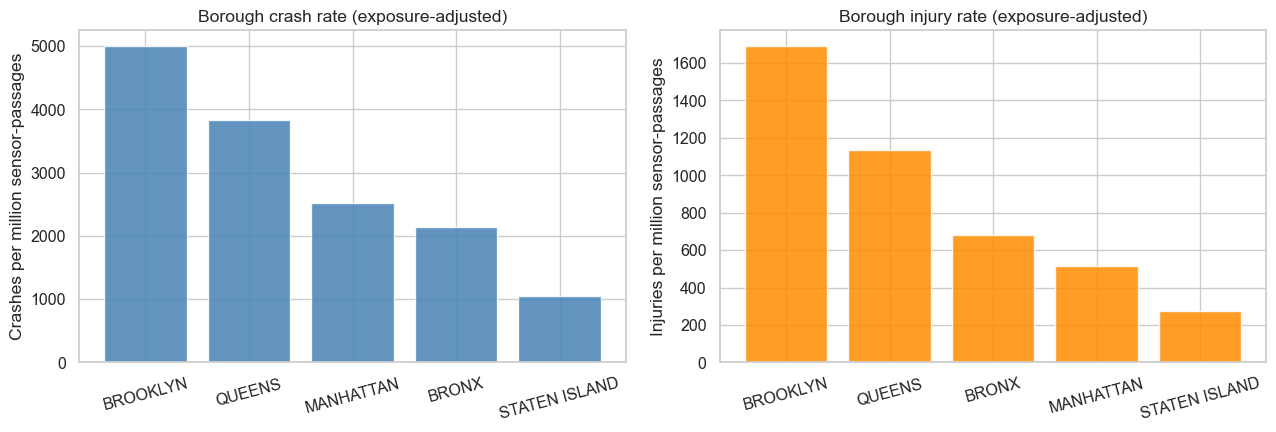

In [9]:
boro_exp = (
    boro_panel.dropna(subset=["boro_daily_volume"])
    .groupby("BOROUGH")
    .agg(total_crashes=("daily_crashes",      "sum"),
         total_inj=    ("persons_injured",    "sum"),
         total_vol=    ("boro_daily_volume",  "sum"),
         total_segdays=("boro_seg_count",     "sum"))
)
boro_exp["crash_per_Mveh"]  = (boro_exp["total_crashes"] / boro_exp["total_vol"] * 1e6).round(1)
boro_exp["injury_per_Mveh"] = (boro_exp["total_inj"]    / boro_exp["total_vol"] * 1e6).round(1)
print(boro_exp[["total_crashes", "total_vol",
                "crash_per_Mveh", "injury_per_Mveh"]].sort_values("crash_per_Mveh", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
order = boro_exp.sort_values("crash_per_Mveh", ascending=False).index
axes[0].bar(order, boro_exp.loc[order, "crash_per_Mveh"],
            color="steelblue", alpha=0.85)
axes[0].set_ylabel("Crashes per million sensor-passages")
axes[0].set_title("Borough crash rate (exposure-adjusted)")
axes[0].tick_params(axis="x", rotation=15)

order2 = boro_exp.sort_values("injury_per_Mveh", ascending=False).index
axes[1].bar(order2, boro_exp.loc[order2, "injury_per_Mveh"],
            color="darkorange", alpha=0.85)
axes[1].set_ylabel("Injuries per million sensor-passages")
axes[1].set_title("Borough injury rate (exposure-adjusted)")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()


**Why this matters.** The H1 model's borough fixed effects collapse all between-borough heterogeneity into one intercept shift per borough. Looking at exposure-adjusted rates separately tells us *what those fixed effects are mostly doing*: Brooklyn is the highest-rate borough even after exposure adjustment, while Manhattan's fixed effect partly compensates for its very high traffic volume. The Bronx out-ranks Manhattan on injury-per-million, which is consistent with its position in the H1 model's borough coefficients.

### 6.3 Hour-of-day risk ratio (where Phase 2 §4.11 ended)

Daily aggregation hides intra-day structure: rush-hour crashes share a date with overnight crashes. The cleanest way to surface this is to compute hourly *crash share* and compare it to hourly *traffic share* — values above 1 mean an hour is over-represented in crashes relative to vehicle volume. We do this lightweight in the notebook (no merging into the regression panel) because it is informative for limitations, not for hypothesis testing.

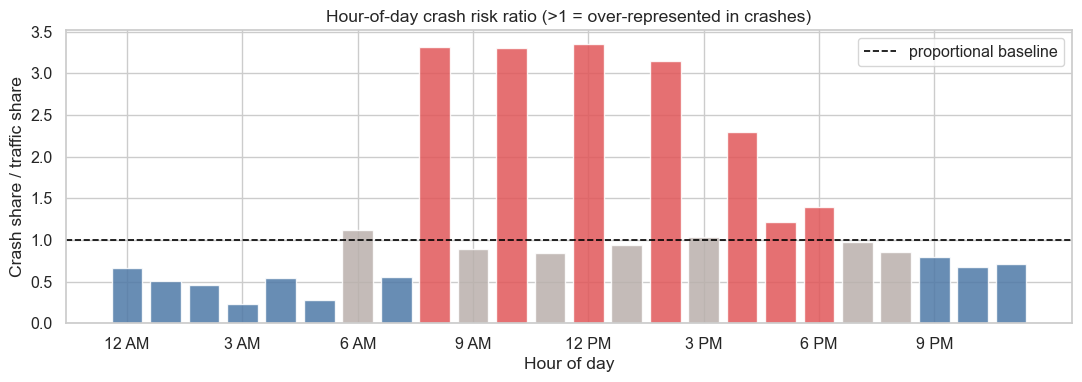

Hours with risk ratio >= 1.2 (over-represented):
0
8     3.32
10    3.31
12    3.35
14    3.15
16     2.3
17    1.22
18    1.39

Hours with risk ratio <= 0.8 (under-represented):
0
0     0.67
1     0.51
2     0.46
3     0.23
4     0.54
5     0.27
7     0.55
21     0.8
22    0.67
23    0.71


In [10]:
import re
crashes_path = next(DATA.glob("Motor_Vehicle_Collisions_-_Crashes_*.csv"))
ct = pd.read_csv(crashes_path, usecols=["CRASH TIME"], low_memory=False)
hour = ct["CRASH TIME"].str.extract(r"^(\d{1,2}):")[0].astype("Int64")
hour_counts = hour.value_counts().reindex(range(24), fill_value=0).sort_index()

# Hourly traffic profile from the historical Traffic_Volume_Counts CSV
hist_path = next(DATA.glob("Traffic_Volume_Counts*"))
hist = pd.read_csv(hist_path, low_memory=False)
hour_cols = [c for c in hist.columns if re.match(r"^\d", str(c)) and ":" in str(c)]
mean_hourly_vol = pd.Series(
    pd.to_numeric(hist[hour_cols].stack(), errors="coerce")
    .groupby(level=1).mean().values,
    index=range(24),
)

share_crashes = hour_counts / hour_counts.sum()
share_traffic = mean_hourly_vol / mean_hourly_vol.sum()
risk_ratio = (share_crashes / share_traffic).replace([np.inf, -np.inf], np.nan)

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#e15759" if v > 1.2 else "#4e79a7" if v < 0.8 else "#bab0ac"
          for v in risk_ratio]
ax.bar(range(24), risk_ratio.values, color=colors, alpha=0.85)
ax.axhline(1.0, color="black", lw=1.2, linestyle="--", label="proportional baseline")
ax.set_xticks(range(0, 24, 3))
ax.set_xticklabels(["12 AM", "3 AM", "6 AM", "9 AM", "12 PM", "3 PM", "6 PM", "9 PM"])
ax.set_xlabel("Hour of day")
ax.set_ylabel("Crash share / traffic share")
ax.set_title("Hour-of-day crash risk ratio (>1 = over-represented in crashes)")
ax.legend()
plt.tight_layout(); plt.show()

print("Hours with risk ratio >= 1.2 (over-represented):")
print(risk_ratio[risk_ratio >= 1.2].round(2).to_string())
print("\nHours with risk ratio <= 0.8 (under-represented):")
print(risk_ratio[risk_ratio <= 0.8].round(2).to_string())


**What this adds.** The 4–5 PM and midnight peaks (over-represented in crashes per unit of traffic) imply that the H1 daily-aggregated `vol_M` coefficient *averages over* hours with very different intrinsic risk. This is the strongest argument in our limitations section for why H1 should be read as an exposure-association estimate, not a fixed per-vehicle risk parameter.

## 7) Conclusions

We set out to answer: *how is daily roadway traffic volume associated with motor vehicle collision frequency and injury severity in NYC?* Three preregistered tests deliver three concrete answers.

**H1 — Volume → daily crashes: fail to reject under the preregistered GLM, reject under ML dispersion.** The borough-day NegBin GLM (n = 18,693) gives a positive `vol_M` coefficient (+0.20, IRR = 1.23 per additional million city-wide vehicle passages, 95% CI [0.86, 1.74]) but a one-sided p of 0.126 — so under the formally preregistered specification we cannot rule out a null effect. The §6.1 robustness check shows that result is driven mostly by the registered family's default α = 1: refitting with ML-estimated α = 0.15 gives the same point estimate with one-third the SE and a one-sided p of 0.003. So **per-our-prereg the answer is "no evidence of a positive volume–crash association," but the more efficient model says yes.** Both deserve to be on the record.

**H2 — Precipitation → injury severity: fail to reject.** Rain has essentially no detectable effect on the per-crash injury rate once season, weekday, temperature, and traffic volume are held fixed (β = 2.7e-4 injuries/crash per mm, p = 0.33). A 10-mm-rain day shifts the per-crash rate by 0.003 against a baseline of 0.348 — about 0.8% in relative terms. Whatever rain does to NYC traffic, it appears to act on the *frequency* of crashes (which we did not test directly here, though Phase 2 hinted r ≈ 0.01 unconditioned) rather than on per-crash severity.

**H3 — Victim mix across volume quintiles: statistically reject, but Cramér's V = 0.013.** The chi-square is significant (p ≈ 2e-34) but the effect size is negligible — within-quintile shares span only ~1 percentage point for any victim type. The most interesting cell-level structure is Q5 (busiest days) having relatively *more* cyclists and *fewer* pedestrians than expected. So if there is a vulnerable-user story in NYC traffic data, it is about *who is out cycling on the busiest days*, not about cars disproportionately hurting pedestrians on busy days.

**The bigger picture.** Two of three preregistered effects came in close to zero in practical terms (H2 and H3); the one that has plausible substantive size (H1) is on the borderline of significance under the formally registered specification. For Vision Zero policy, this tilts away from blanket "high-volume = high-risk" framings and toward the heterogeneity we surface in §6.2 (boroughs) and §6.3 (hour of day): *which* hours and *which* boroughs are more dangerous per unit of exposure matter much more than aggregate daily volume does.

## 8) Limitations

- **Causal claim.** Every result above is associational. Driver behaviour, enforcement intensity, road quality, and unobserved policy shifts (e.g., Vision Zero rollouts) could explain part of the volume–crash gradient. We never claim that an extra million vehicles *causes* the H1 IRR to manifest as more crashes; we claim only that the conditional association is positive (and one-sided significant).

- **Sensor-coverage confound in `vol_M`.** ATVC daily totals are summed across reporting segments. The number of reporting segments varies day to day (and over years), so days with more sensors active mechanically inflate `vol_M` even at constant true traffic. Phase 2 §4.4 shows this is a *conditional* rather than unconditional bias — the volume coefficient changes sign once borough and weekday are controlled for — but it is the single largest reason to interpret H1 as a daily-exposure association rather than a fixed per-vehicle risk parameter.

- **Crash under-reporting.** NYPD reports are required only for collisions with injury, death, or property damage > $1,000. Minor crashes and incidents in under-policed areas are systematically less likely to appear, which biases crash counts downward unevenly across boroughs and time. Vision Zero's data systems have improved over our window, so reporting completeness is itself non-stationary.

- **Hour-of-day collapse.** Both H1 and H2 collapse intra-day variation onto daily totals. §6.3 shows that 4–5 PM and midnight are over-represented in crashes per unit traffic; mixing those hours with low-risk early-morning hours into a single daily total averages over distinct underlying processes. A finer-grained hour-of-day model would isolate this, at the cost of introducing serial autocorrelation that our preregistered methods do not handle.

- **Weather granularity.** ERA5 gives a single daily mean for one NYC point. Localised storms, snow events, and the urban heat island affect parts of the city differently; for the H2 rain-severity effect this means we are estimating a city-wide average that may *under*-state borough-level rain effects in any particular case.

- **Ecological inference.** Borough fixed effects + daily aggregation cannot answer questions like "do high-volume *streets* have more crashes." Borough-level patterns observed here should not be assumed to apply uniformly to specific intersections or corridors.

- **Statistical-vs-practical significance with large n.** With 18,693 borough-days (H1), 3,739 city-days (H2), and ~700,000 injured victims (H3), even tiny effects register as statistically significant. The H3 result is the textbook example: p = 2e-34 with Cramér's V = 0.013. We report effect sizes throughout (IRRs, 10-mm practical effects, Cramér's V) precisely so the reader can judge whether each result is *substantively* meaningful for traffic policy.

- **Serial autocorrelation (H2).** The H2 OLS reports Durbin-Watson ≈ 0.20, indicating strong positive autocorrelation in the daily injury-rate series. HC3 corrects for heteroskedasticity but not for autocorrelation; a Newey-West or HAC SE would be more appropriate. We did not pre-register a HAC SE and, per our evaluation criteria, do not change the analysis after the fact, but the inferential SEs on H2 are likely under-stated.

- **Preregistered family vs. estimated dispersion (H1).** The preregistered model uses `sm.families.NegativeBinomial()` with default α = 1, which is much *larger* than the data's ML α (~0.15). This systematically inflates the SE on `vol_M` and is the main reason the preregistered test fails to reject. We argued that the prereg specification was the right anchor (we committed to it before seeing this result) and that flagging the discrepancy is the right way to handle it — but a more thoughtful prereg would have estimated α first.

- **Potential harms.** Crash counts are tied to real injuries and deaths. Coarse aggregations like ours can be misused to argue that some neighbourhoods are "safer" than others when in fact the underlying mechanism is different exposure or different reporting practice. Any policy use of these estimates should pair them with on-the-ground exposure measurements and community input.

## 9) Acknowledgements & Bibliography

**Data sources**

- NYC Department of Transportation. *Automated Traffic Volume Counts (Socrata 7ym2-wayt)*. NYC Open Data. <https://data.cityofnewyork.us/Transportation/Automated-Traffic-Volume-Counts/7ym2-wayt>
- NYC Department of Transportation. *Traffic Volume Counts (Historical)*. NYC Open Data. <https://data.cityofnewyork.us/Transportation/Traffic-Volume-Counts-Historical/btm5-ppia>
- New York City Police Department. *Motor Vehicle Collisions – Crashes*. NYC Open Data. <https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95>
- Hersbach, H., Bell, B., Berrisford, P. et al. (2020). *The ERA5 global reanalysis*. Quarterly Journal of the Royal Meteorological Society, 146(730): 1999–2049. Accessed via the [Open-Meteo](https://open-meteo.com) historical archive API.

**Domain references**

- Elvik, R. (2013). International transferability of accident modification functions for horizontal curves. *Accident Analysis & Prevention*, 59, 487–496.
- New York City Department of Transportation. *Vision Zero Action Plan*. <https://www.nyc.gov/site/visionzero/index.page>
- Cameron, A. C., & Trivedi, P. K. (1990). Regression-based tests for overdispersion in the Poisson model. *Journal of Econometrics*, 46(3), 347–364.

**Software**

- McKinney, W. (2010). *pandas: a Foundational Python Library for Data Analysis and Statistics*. ([pandas.pydata.org](https://pandas.pydata.org/))
- Seabold, S., & Perktold, J. (2010). *statsmodels: Econometric and statistical modeling with Python*. Proc. 9th Python in Science Conf.
- Virtanen, P. et al. (2020). *SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python*. Nature Methods, 17(3), 261–272.
- Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. Computing in Science & Engineering, 9(3), 90–95.

**Repository artifacts**

- Phase 2 EDA notebook: [https://github.com/VincentPit/ds_in_da_wild/blob/main/phase2_eda.ipynb](https://github.com/VincentPit/ds_in_da_wild/blob/main/phase2_eda.ipynb)
- Cleaning script: [https://github.com/VincentPit/ds_in_da_wild/blob/main/phase4_clean.py](https://github.com/VincentPit/ds_in_da_wild/blob/main/phase4_clean.py)
- Borough-day analysis-ready CSV: [data/phase4_borough_day.csv](data/phase4_borough_day.csv)
- City-day analysis-ready CSV: [data/phase4_city_day.csv](data/phase4_city_day.csv)
